# GTEx k-means clustering of gene expression data using different methods

This notebook evaluates the ability of different dimensionality reduction methods to preserve biological tissue structure in GTEx gene expression data. It performs GPU-accelerated K-means clustering (using cuML) on sample embeddings from multiple methods, including raw RNA-Seq, CLAMP base and GO biological process CLAMP full models from both the FBM and RSVD pipelines, PCA, ICA, NMF, PLIER, Flashier, MOFA-flex, and GenomicSuperSignature. It then measures clustering quality using the Adjusted Rand Index (ARI). The analysis runs an ensemble of K-meansto determine which embeddings best capture the underlying tissue biology.

## Libraries

💡 **Environment:** `gpu-kmeans` 

In [1]:
import csv
import gc
from pathlib import Path
import numpy as np
import pandas as pd
from pyprojroot.here import here
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score as ari
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
import cupy as cp
from cuml.cluster import KMeans as cuKMeans
import matplotlib.pyplot as plt
import pickle
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import re
from scipy.stats import mannwhitneyu
readRDS = ro.r["readRDS"]
import yaml

During startup - Warning messages:
1: package ‘methods’ was built under R version 4.6.0 
2: package ‘datasets’ was built under R version 4.6.0 
3: package ‘utils’ was built under R version 4.6.0 
4: package ‘grDevices’ was built under R version 4.6.0 
5: package ‘grDevices’ in options("defaultPackages") was not found 
6: package ‘graphics’ was built under R version 4.6.0 
7: package ‘graphics’ in options("defaultPackages") was not found 
8: package ‘stats’ was built under R version 4.6.0 
9: package ‘stats’ in options("defaultPackages") was not found 


In [2]:
with open(here("config.yaml"), "r") as f:
    _cfg = yaml.safe_load(f)

MODEL_COLORS = _cfg["MODEL_COLORS"]
RNASEQ_FRACTION_COLORS = _cfg["RNASEQ_FRACTION_COLORS"]

def get_model_color(model_name):
    """Get consistent color for a model name."""
    return MODEL_COLORS.get(model_name, "#333333")

def get_fraction_color(fraction_label):
    """Get consistent color for RNA-Seq fraction label."""
    return RNASEQ_FRACTION_COLORS.get(str(fraction_label), "#333333")


# Input

In [3]:
path = here('data/gtex/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt')

gtex_meta = pd.read_csv(
    path,
    sep='\t',
    header=0,
    dtype=str,
    quoting=csv.QUOTE_NONE,   
    engine='python',
    comment=None,            
    keep_default_na=False,
    on_bad_lines='warn'     
)

print(gtex_meta.shape)
gtex_meta.head()

(22951, 63)


,SAMPID,SMATSSCR,SMCENTER,SMPTHNTS,SMRIN,SMTS,SMTSD,SMUBRID,SMTSISCH,SMTSPAX,...,SME1ANTI,SMSPLTRD,SMBSMMRT,SME1SNSE,SME1PCTS,SMRRNART,SME1MPRT,SMNUM5CD,SMDPMPRT,SME2PCTS
0,GTEX-1117F-0003-SM-58Q7G,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
1,GTEX-1117F-0003-SM-5DWSB,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
2,GTEX-1117F-0003-SM-6WBT7,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
3,GTEX-1117F-0011-R10a-SM-AHZ7F,,"B1, A1",,,Brain,Brain - Frontal Cortex (BA9),0009834,1193,,...,,,,,,,,,,
4,GTEX-1117F-0011-R10b-SM-CYKQ8,,"B1, A1",,7.2,Brain,Brain - Frontal Cortex (BA9),0009834,1193,,...,,,,,,,,,,


In [4]:
display(gtex_meta['SMTSD'].value_counts())
total_tissues = len(gtex_meta['SMTSD'].value_counts())
total_tissues

SMTSD
Whole Blood                                  3288
Muscle - Skeletal                            1132
Lung                                          867
Skin - Sun Exposed (Lower leg)                849
Thyroid                                       812
Artery - Tibial                               770
Adipose - Subcutaneous                        763
Nerve - Tibial                                722
Heart - Left Ventricle                        689
Skin - Not Sun Exposed (Suprapubic)           638
Esophagus - Mucosa                            622
Adipose - Visceral (Omentum)                  564
Esophagus - Muscularis                        559
Cells - Cultured fibroblasts                  527
Breast - Mammary Tissue                       480
Heart - Atrial Appendage                      452
Artery - Aorta                                450
Colon - Transverse                            432
Brain - Frontal Cortex (BA9)                  425
Testis                                      

55

Keep samples in expression and in metadata

In [5]:
gtex_data = pd.read_csv(here('output/01_model_building/02_gtex/01_CLAMP/df_gtex_fbm_filt.csv'), index_col=0)

In [6]:
meta = gtex_meta.copy()
if meta.index.name != "SAMPID":
    meta = meta.set_index("SAMPID")

sample_ids_expr = pd.Index(gtex_data.columns.astype(str).str.strip(), name="SAMPID")
sample_ids_meta = meta.index.astype(str).str.strip()
common_ids = sample_ids_expr.intersection(sample_ids_meta)

if len(common_ids) == 0:
    raise ValueError("No overlapping sample IDs between expression and metadata.")

gtex_data_common = gtex_data.loc[:, common_ids]    
meta_common = meta.loc[common_ids] 

In [7]:
MIN_SAMPLES = 50
tissue_counts = meta_common["SMTSD"].value_counts()
valid_tissues = tissue_counts[tissue_counts >= MIN_SAMPLES].index

mask = meta_common["SMTSD"].isin(valid_tissues)
meta_common = meta_common[mask]
common_ids = meta_common.index
gtex_data_common = gtex_data_common.loc[:, common_ids]

total_tissues = len(valid_tissues)
print(f"Tissues with >= {MIN_SAMPLES} samples: {total_tissues}")
print(tissue_counts[tissue_counts >= MIN_SAMPLES])

Tissues with >= 50 samples: 49
SMTSD
Muscle - Skeletal                            803
Whole Blood                                  755
Skin - Sun Exposed (Lower leg)               701
Adipose - Subcutaneous                       663
Artery - Tibial                              663
Thyroid                                      653
Nerve - Tibial                               619
Skin - Not Sun Exposed (Suprapubic)          604
Lung                                         578
Esophagus - Mucosa                           555
Adipose - Visceral (Omentum)                 541
Esophagus - Muscularis                       515
Cells - Cultured fibroblasts                 504
Breast - Mammary Tissue                      459
Artery - Aorta                               432
Heart - Left Ventricle                       432
Heart - Atrial Appendage                     429
Colon - Transverse                           406
Esophagus - Gastroesophageal Junction        375
Colon - Sigmoid                 

In [8]:
y_true = meta_common.loc[common_ids, "SMTSD"].astype(str).to_numpy()

# GPU kmeans ensemble

## Parameters

In [9]:
BASE_SEED = 10000
N_REPS_PER_K = 50
k_values = [total_tissues]

In [10]:
KMEANS_CACHE_DIR = Path(here("output/03_model_biology/01_gtex/00_kmeans_clustering/kmeans_results"))
KMEANS_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def extract_B_matrix(rds_obj):
    """Extract a B matrix from an RDS object into a pandas DataFrame."""
    B_matrix = rds_obj.rx2("B")

    with localconverter(ro.default_converter + pandas2ri.converter):
        B_values = ro.conversion.rpy2py(B_matrix)

    df = pd.DataFrame(
        data=B_values,
        index=B_matrix.rownames if B_matrix.rownames else None,
        columns=B_matrix.colnames if B_matrix.colnames else None,
    )
    return df


def load_rds_B_matrix(rel_path, sample_names_rel_path=None):
    B = extract_B_matrix(readRDS(str(here(rel_path))))

    if sample_names_rel_path is None:
        return B

    sample_names = pd.Index(
        [str(x) for x in readRDS(str(here(sample_names_rel_path)))],
        dtype="object",
    )

    current_columns = pd.Index(B.columns.astype(str))
    if len(current_columns.intersection(sample_names)) > 0:
        return B

    if B.shape[1] != len(sample_names):
        raise ValueError(
            f"Sample-name fallback length mismatch for {rel_path}: "
            f"B has {B.shape[1]} columns but {sample_names_rel_path} has {len(sample_names)} entries."
        )

    B.columns = sample_names
    return B


def prepare_embedding_for_kmeans(B, meta):
    B = B.copy()
    B.columns = B.columns.astype(str).str.strip()

    common_ids = B.columns.intersection(meta.index)
    if len(common_ids) == 0:
        raise ValueError("No overlapping sample IDs between B and metadata.")

    meta_f = meta.loc[common_ids]
    tissue_counts = meta_f["SMTSD"].value_counts()
    valid_tissues = tissue_counts[tissue_counts >= MIN_SAMPLES].index
    mask = meta_f["SMTSD"].isin(valid_tissues)
    meta_f = meta_f[mask]
    common_ids = meta_f.index

    B_t = B.loc[:, common_ids].T.astype(np.float32)
    y_true = meta_f["SMTSD"].astype(str).to_numpy()
    n_tissues = len(valid_tissues)
    return B_t, y_true, n_tissues


def load_or_run_cached(cache_key, compute_fn):
    cache_path = KMEANS_CACHE_DIR / f"{cache_key}.pkl"

    if cache_path.exists():
        print(f"Loading cached results from {cache_path}")
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    results = compute_fn()

    with open(cache_path, "wb") as f:
        pickle.dump(results, f)

    print(f"Saved results to {cache_path}")
    return results


def run_embedding_kmeans(B, meta, method_name, cache_key):
    B_t, y_true, n_tissues = prepare_embedding_for_kmeans(B, meta)
    emb_k_values = [n_tissues]
    results = load_or_run_cached(
        cache_key,
        lambda: run_kmeans_compare_scaling(B_t, y_true, method_name, emb_k_values),
    )
    print(f"{method_name}: Best k: {results['best_k']}, Mean ARI: {results['scaled_ari']:.4f}")
    return results


def run_kmeans_compare_scaling(B_t, y_true, method_name, emb_k_values=None):
    """
    Run k-means clustering.
    Returns the best k based on mean ARI.

    Parameters:
    -----------
    B_t : array-like
        Transposed data matrix (samples x features)
    y_true : array-like
        True labels for ARI computation
    method_name : str
        Name of the method (for labeling results)
    emb_k_values : list, optional
        k values to try. Defaults to global k_values.

    Returns:
    --------
    dict with keys:
        - 'best_results_df': DataFrame with results
        - 'best_k_results_df': DataFrame filtered to best k
        - 'best_k': optimal number of clusters
        - 'scaled_ari': mean ARI at best k
    """
    if emb_k_values is None:
        emb_k_values = k_values

    X = StandardScaler().fit_transform(B_t)
    X_gpu = cp.asarray(X.astype("float32"))

    records = []
    for k in emb_k_values:
        for rep in range(N_REPS_PER_K):
            km = cuKMeans(
                n_clusters=k,
                init="k-means++",
                random_state=BASE_SEED + k * 1000 + rep,
                max_iter=300,
                tol=1e-4,
                verbose=0
            )
            labels_gpu = km.fit_predict(X_gpu)
            labels = cp.asnumpy(labels_gpu)
            ari = adjusted_rand_score(y_true, labels)

            records.append({
                "k": k,
                "rep": rep,
                "seed": BASE_SEED + k * 1000 + rep,
                "ari": ari,
            })

    del X_gpu
    cp.get_default_memory_pool().free_all_blocks()

    df = pd.DataFrame.from_records(records)
    mean_ari = df.groupby("k")["ari"].mean()
    best_k = mean_ari.idxmax()
    best_k_df = df[df["k"] == best_k]

    print(f"{method_name}: Best k: {best_k}, Mean ARI: {mean_ari[best_k]:.4f}")

    return {
        'best_results_df': df,
        'best_k_results_df': best_k_df,
        'best_k': best_k,
        'scaled_ari': mean_ari[best_k],
    }


## RNA-Seq

K-means clustering is highly sensitive to the number of input features, which is particularly important when comparing full RNA-seq expression profiles (highest dimensional) to lower-dimensional latent variable (LV) representations. High dimensionality can also reduce the discriminative value of Euclidean distances: as dimensionality increases, pairwise distances between samples tend to become more similar (an “equidistance” effect), making it harder for k-means to separate clusters reliably and exacerbating the curse of dimensionality. To reduce these effects, we restricted the RNA-seq input to the most variable genes and ran k-means using 100% of this set, then repeated the analysis using 75%, 50%, and 25% of the most variable genes.

In [11]:
# Gene selection by variance configuration
GENE_FRACTIONS = [1.0, 0.75, 0.50, 0.25, 0.10, 0.05, 0.01]


def compute_rnaseq_topvar_results():
    B = gtex_data_common.copy()
    B.columns = B.columns.astype(str).str.strip()

    common_ids = B.columns.intersection(meta_common.index)
    B_common = B.loc[:, common_ids]

    n_genes = len(B_common.index)
    y_true = meta_common.loc[common_ids, "SMTSD"].astype(str).to_numpy()
    rnaseq_k_values = [total_tissues]

    gene_variances = B_common.var(axis=1)
    genes_by_variance = gene_variances.sort_values(ascending=False).index.tolist()

    print(f"Total genes: {n_genes}")
    print(f"Total samples: {len(common_ids)}")
    print(f"k = {total_tissues} tissues")

    results_by_fraction = {}

    for frac in GENE_FRACTIONS:
        pct = int(frac * 100)
        run_label = f"rnaseq_{pct}pct_topvar"
        print(f"\n{'=' * 50}")
        print(f"Running: {run_label}")

        n_select = int(n_genes * frac)
        selected_genes = genes_by_variance[:n_select]
        print(f"  Selected top {n_select} most variable genes")

        B_subset = B_common.loc[selected_genes, :]
        B_t = B_subset.T.astype(np.float32)

        results_by_fraction[run_label] = run_kmeans_compare_scaling(B_t, y_true, run_label, rnaseq_k_values)

    print("\n" + "=" * 50)
    print("\nTop Variable Genes Analysis Summary:")
    for label, results in results_by_fraction.items():
        print(f"  {label}: Best k = {results['best_k']}, ARI = {results['scaled_ari']:.4f}")

    return results_by_fraction


rnaseq_topvar_results = load_or_run_cached(
    "gtex_rnaseq_topvar_results",
    compute_rnaseq_topvar_results,
)


Loading cached results from /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/01_gtex/00_kmeans_clustering/kmeans_results/gtex_rnaseq_topvar_results.pkl


In [12]:
# Select best configuration from top variable genes analysis
best_mean_ari = -1
best_run_label = None

for run_label, results in rnaseq_topvar_results.items():
    ari = results['scaled_ari']
    if ari > best_mean_ari:
        best_mean_ari = ari
        best_run_label = run_label

print(f"Best RNA-Seq configuration: {best_run_label}")
print(f"  Best k: {rnaseq_topvar_results[best_run_label]['best_k']}")
print(f"  Mean ARI: {best_mean_ari:.4f}")

# Set the best results for use in comparisons
gtex_rnaseq_kmeans_results_df = rnaseq_topvar_results[best_run_label]['best_results_df']
best_k_gtex_rnaseq_kmeans_results_df = rnaseq_topvar_results[best_run_label]['best_k_results_df']

# Create best_k_rnaseq_results for the gene fraction comparison plots
best_k_rnaseq_results = {}
for run_label, results in rnaseq_topvar_results.items():
    # Extract fraction from run_label (e.g., 'rnaseq_75pct_topvar' -> 0.75)
    pct = int(run_label.split('_')[1].replace('pct', ''))
    frac = pct / 100.0

    df = results['best_k_results_df'].copy()
    df['frac'] = frac
    best_k_rnaseq_results[run_label] = df


Best RNA-Seq configuration: rnaseq_5pct_topvar
  Best k: 49
  Mean ARI: 0.6130


In [13]:
for run_label, results in rnaseq_topvar_results.items():
    print(f"{run_label}: Best k: {results['best_k']}, ARI: {results['scaled_ari']:.4f}")


rnaseq_100pct_topvar: Best k: 49, ARI: 0.5695
rnaseq_75pct_topvar: Best k: 49, ARI: 0.5661
rnaseq_50pct_topvar: Best k: 49, ARI: 0.5848
rnaseq_25pct_topvar: Best k: 49, ARI: 0.5997
rnaseq_10pct_topvar: Best k: 49, ARI: 0.6075
rnaseq_5pct_topvar: Best k: 49, ARI: 0.6130
rnaseq_1pct_topvar: Best k: 49, ARI: 0.6022


In [14]:
# Select best configuration from top variable genes analysis
best_mean_ari = -1
best_run_label = None

for run_label, results in rnaseq_topvar_results.items():
    ari = results['scaled_ari']
    if ari > best_mean_ari:
        best_mean_ari = ari
        best_run_label = run_label

print(f"Best RNA-Seq configuration: {best_run_label}")
print(f"  Best k: {rnaseq_topvar_results[best_run_label]['best_k']}")
print(f"  Mean ARI: {best_mean_ari:.4f}")

# Set the best results for use in comparisons
gtex_rnaseq_results = rnaseq_topvar_results[best_run_label]
gtex_rnaseq_kmeans_results_df = gtex_rnaseq_results['best_results_df']
best_k_gtex_rnaseq_kmeans_results_df = gtex_rnaseq_results['best_k_results_df']


Best RNA-Seq configuration: rnaseq_5pct_topvar
  Best k: 49
  Mean ARI: 0.6130


<!-- ## RNA-Seq Null Distribution (shuffled labels) -->

In [15]:
# def compute_rnaseq_null_distribution():
#     B = gtex_data.copy()
#     B.columns = B.columns.astype(str).str.strip()

#     common_ids = B.columns.intersection(meta_common.index)
#     B_common = B.loc[:, common_ids]

#     gene_variances = B_common.var(axis=1)
#     genes_by_variance = gene_variances.sort_values(ascending=False).index.tolist()

#     best_pct = int(best_run_label.split("_")[1].replace("pct", ""))
#     n_select = int(len(genes_by_variance) * best_pct / 100.0)
#     B_t = B_common.loc[genes_by_variance[:n_select], :].T.astype(np.float32)
#     y_true_local = meta_common.loc[common_ids, "SMTSD"].astype(str).to_numpy()

#     X = StandardScaler().fit_transform(B_t)
#     X_gpu = cp.asarray(X.astype("float32"))
#     rng = np.random.default_rng(BASE_SEED + 99999)
#     records = []

#     for k in k_values:
#         for rep in range(N_REPS_PER_K):
#             y_shuffled = rng.permutation(y_true_local)
#             km = cuKMeans(
#                 n_clusters=k,
#                 init="k-means++",
#                 random_state=BASE_SEED + k * 1000 + rep,
#                 max_iter=300,
#                 tol=1e-4,
#                 verbose=0,
#             )
#             labels = cp.asnumpy(km.fit_predict(X_gpu))
#             records.append({
#                 "k": k,
#                 "rep": rep,
#                 "seed": BASE_SEED + k * 1000 + rep,
#                 "ari": adjusted_rand_score(y_shuffled, labels),
#             })

#     del X_gpu
#     cp.get_default_memory_pool().free_all_blocks()

#     df = pd.DataFrame.from_records(records)
#     mean_ari = df.groupby("k")["ari"].mean()
#     best_k = mean_ari.idxmax()

#     print(f"Null (shuffled RNA-Seq, {best_pct}% top-var genes): Best k: {best_k}, Mean ARI: {mean_ari[best_k]:.4f}")

#     return {
#         "best_results_df": df,
#         "best_k_results_df": df[df["k"] == best_k],
#         "best_k": best_k,
#         "scaled_ari": mean_ari[best_k],
#     }


# gtex_rnaseq_null_results = load_or_run_cached(
#     "gtex_rnaseq_null_distribution",
#     compute_rnaseq_null_distribution,
# )


## CLAMP models

In [16]:
CLAMP_RDS_FILES = {
    "CLAMPbase": {
        "model_path": "output/01_model_building/02_gtex/01_CLAMP/CLAMPbase.rds"
    },
    "CLAMPfull": {
        "model_path": "output/01_model_building/02_gtex/01_CLAMP/CLAMPfull.rds"
    },
}

clamp_embeddings = {}

for model_name, spec in CLAMP_RDS_FILES.items():
    clamp_embeddings[model_name] = load_rds_B_matrix(
        spec["model_path"],
    )
    print(f"{model_name}: {clamp_embeddings[model_name].shape}")


CLAMPbase: (578, 17382)


CLAMPfull: (578, 17382)


In [17]:
gtex_CLAMP_base_results = run_embedding_kmeans(
    clamp_embeddings["CLAMPbase"],
    meta,
    "CLAMP_base",
    "gtex_CLAMP_base_kmeans",
)

gtex_CLAMP_base_kmeans_results_df = gtex_CLAMP_base_results['best_results_df']
best_k_gtex_CLAMP_base_kmeans_results_df = gtex_CLAMP_base_results['best_k_results_df']

Loading cached results from /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/01_gtex/00_kmeans_clustering/kmeans_results/gtex_CLAMP_base_kmeans.pkl
CLAMP_base: Best k: 49, Mean ARI: 0.6321


In [18]:
gtex_CLAMPfull_results = run_embedding_kmeans(
    clamp_embeddings["CLAMPfull"],
    meta,
    "CLAMPfull",
    "gtex_CLAMPfull_kmeans",
)

gtex_CLAMPfull_kmeans_results_df = gtex_CLAMPfull_results['best_results_df']
best_k_gtex_CLAMP_full_kmeans_results_df = gtex_CLAMPfull_results['best_k_results_df']

Loading cached results from /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/01_gtex/00_kmeans_clustering/kmeans_results/gtex_CLAMPfull_kmeans.pkl
CLAMPfull: Best k: 49, Mean ARI: 0.6497


In [19]:
from sklearn.cluster import KMeans as skKMeans

model_dir = Path(here('output/03_model_biology/01_gtex/00_kmeans_clustering/kmeans_models'))
model_dir.mkdir(parents=True, exist_ok=True)

B_clamp_full = clamp_embeddings["CLAMPfull"].copy()
B_clamp_full.columns = B_clamp_full.columns.astype(str).str.strip()
common_ids_clamp = B_clamp_full.columns.intersection(meta_common.index)
B_t_clamp = B_clamp_full.loc[:, common_ids_clamp].T.astype(np.float32)

best_k = gtex_CLAMPfull_results['best_k']

scaler = StandardScaler()
X_clamp = scaler.fit_transform(B_t_clamp)

best_row = gtex_CLAMPfull_results['best_k_results_df'].loc[
    gtex_CLAMPfull_results['best_k_results_df']['ari'].idxmax()
]
best_seed = int(best_row['seed'])
final_ari = float(best_row['ari'])

X_gpu = cp.asarray(X_clamp.astype("float32"))
final_km = cuKMeans(
    n_clusters=best_k,
    init="k-means++",
    random_state=best_seed,
    max_iter=300,
    tol=1e-4,
    verbose=0,
)
final_km.fit(X_gpu)

# Convert to sklearn so downstream notebooks don't need cuml
centers_np = cp.asnumpy(final_km.cluster_centers_)
sklearn_km = skKMeans(n_clusters=best_k, init=centers_np, n_init=1, max_iter=1)
sklearn_km.fit(centers_np)
sklearn_km.cluster_centers_ = centers_np

del X_gpu
cp.get_default_memory_pool().free_all_blocks()

model_bundle = {
    'model': sklearn_km,
    'scaler': scaler,
    'best_k': best_k,
    'best_seed': best_seed,
    'ari': final_ari,
    'feature_names': list(B_t_clamp.columns),
    'sample_ids': list(B_t_clamp.index),
}

save_path = model_dir / 'gtex_CLAMPfull_kmeans_model.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(model_bundle, f)

print(f"Model saved to: {save_path}")
print(f"  best_k={best_k}, seed={best_seed}, ARI={final_ari:.4f}")


Model saved to: /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/01_gtex/00_kmeans_clustering/kmeans_models/gtex_CLAMPfull_kmeans_model.pkl
  best_k=49, seed=59045, ARI=0.7249


## PLIER

In [20]:
gtex_PLIER_B = load_rds_B_matrix('output/01_model_building/02_gtex/02_PLIER/PLIER.rds')

gtex_PLIER_results = run_embedding_kmeans(
    gtex_PLIER_B,
    meta,
    "PLIER",
    "gtex_PLIER_kmeans",
)

gtex_PLIER_kmeans_results_df = gtex_PLIER_results['best_results_df']
best_k_gtex_PLIER_kmeans_results_df = gtex_PLIER_results['best_k_results_df']

Loading cached results from /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/01_gtex/00_kmeans_clustering/kmeans_results/gtex_PLIER_kmeans.pkl
PLIER: Best k: 49, Mean ARI: 0.6446


## GenomicSuperSignature

In [21]:
gtex_GenomicSuperSignature_B = pd.read_csv(here("output/01_model_building/02_gtex/09_GenomicSuperSignature/GenomicSuperSignature/gtex_B.csv"), index_col=0)

gtex_GenomicSuperSignature_results = run_embedding_kmeans(
    gtex_GenomicSuperSignature_B,
    meta,
    "GenomicSuperSignature",
    "gtex_GenomicSuperSignature_kmeans",
)

gtex_GenomicSuperSignature_kmeans_results_df = gtex_GenomicSuperSignature_results['best_results_df']
best_k_gtex_GenomicSuperSignature_kmeans_results_df = gtex_GenomicSuperSignature_results['best_k_results_df']


Loading cached results from /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/01_gtex/00_kmeans_clustering/kmeans_results/gtex_GenomicSuperSignature_kmeans.pkl
GenomicSuperSignature: Best k: 49, Mean ARI: 0.3109


## Flashier

In [22]:
gtex_flashier_B = pd.read_csv(here("output/01_model_building/02_gtex/04_flashier/flashier/gtex_B.csv"), index_col=0)

gtex_flashier_results = run_embedding_kmeans(
    gtex_flashier_B,
    meta,
    "Flashier",
    "gtex_flashier_kmeans",
)

gtex_flashier_kmeans_results_df = gtex_flashier_results['best_results_df']
best_k_gtex_flashier_kmeans_results_df = gtex_flashier_results['best_k_results_df']

Loading cached results from /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/01_gtex/00_kmeans_clustering/kmeans_results/gtex_flashier_kmeans.pkl
Flashier: Best k: 49, Mean ARI: 0.5819


## MOFA FLEX BP

In [23]:
gtex_mofabc_B = pd.read_csv(here("output/01_model_building/02_gtex/06_MOFA_FLEX_PRIOR/MOFA_FLEX_PRIOR/B_matrix.csv"), index_col=0)

gtex_mofabc_results = run_embedding_kmeans(
    gtex_mofabc_B,
    meta,
    "MOFA-FLEX_BP",
    "gtex_mofabc_kmeans",
)

gtex_mofabc_kmeans_results_df = gtex_mofabc_results['best_results_df']
best_k_gtex_mofabc_kmeans_results_df = gtex_mofabc_results['best_k_results_df']


Loading cached results from /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/01_gtex/00_kmeans_clustering/kmeans_results/gtex_mofabc_kmeans.pkl
MOFA-FLEX_BP: Best k: 49, Mean ARI: 0.3911


## PCA

In [24]:
gtex_pca_B = pd.read_pickle(here('output/01_model_building/02_gtex/03_PCA_NMF_ICA/pca/gtex_pca_B.pkl'))

gtex_pca_results = run_embedding_kmeans(
    gtex_pca_B,
    meta,
    "PCA",
    "gtex_pca_kmeans",
)

gtex_pca_kmeans_results_df = gtex_pca_results['best_results_df']
best_k_gtex_pca_kmeans_results_df = gtex_pca_results['best_k_results_df']

Loading cached results from /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/01_gtex/00_kmeans_clustering/kmeans_results/gtex_pca_kmeans.pkl
PCA: Best k: 49, Mean ARI: 0.2529


## ICA

In [25]:
gtex_ica_B = pd.read_pickle(here('output/01_model_building/02_gtex/03_PCA_NMF_ICA/ica/gtex_ica_B.pkl'))

gtex_ica_results = run_embedding_kmeans(
    gtex_ica_B,
    meta,
    "ICA",
    "gtex_ica_kmeans",
)

gtex_ica_kmeans_results_df = gtex_ica_results['best_results_df']
best_k_gtex_ica_kmeans_results_df = gtex_ica_results['best_k_results_df']

Loading cached results from /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/01_gtex/00_kmeans_clustering/kmeans_results/gtex_ica_kmeans.pkl
ICA: Best k: 49, Mean ARI: 0.2756


## NMF

In [26]:
gtex_nmf_B = pd.read_pickle(here('output/01_model_building/02_gtex/03_PCA_NMF_ICA/nmf/gtex_nmf_B.pkl'))

gtex_nmf_results = run_embedding_kmeans(
    gtex_nmf_B,
    meta,
    "NMF",
    "gtex_nmf_kmeans",
)

gtex_nmf_kmeans_results_df = gtex_nmf_results['best_results_df']
best_k_gtex_nmf_kmeans_results_df = gtex_nmf_results['best_k_results_df']

Loading cached results from /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/01_gtex/00_kmeans_clustering/kmeans_results/gtex_nmf_kmeans.pkl
NMF: Best k: 49, Mean ARI: 0.6233


<!-- ## WGCNA (excluded) -->

In [27]:
# gtex_wgcna_B = pd.read_csv(here('output/01_model_building/02_gtex/07_WGCNA/wgcna/gtex_wgcna_B.csv'), index_col=0)

# gtex_wgcna_results = run_embedding_kmeans(
#     gtex_wgcna_B,
#     meta,
#     "WGCNA",
#     "gtex_wgcna_kmeans",
# )

# gtex_wgcna_kmeans_results_df = gtex_wgcna_results['best_results_df']
# best_k_gtex_wgcna_kmeans_results_df = gtex_wgcna_results['best_k_results_df']


In [28]:
# # Summary: Scaling approach comparison for each method
# scaling_comparison = []

# method_results = {
#     'rnaseq': gtex_rnaseq_results,
#     'CLAMP_base': gtex_CLAMP_base_results,
#     'CLAMP_full_BP': gtex_CLAMP_full_BP_results,
#     'GenomicSuperSignature': gtex_GenomicSuperSignature_results,
#     'flashier': gtex_flashier_results,
#     'mofa': gtex_mofa_results,
#     'mofabc': gtex_mofabc_results,
#     'pca': gtex_pca_results,
#     'ica': gtex_ica_results,
#     'nmf': gtex_nmf_results,
#     'PLIER': gtex_PLIER_results,
#     'wgcna': gtex_wgcna_results,
# }

# for method, results in method_results.items():
#     scaling_comparison.append({
#         'Method': method,
#         'Best Approach': results['best_approach'],
#         'Best k': results['best_k'],
#         'Scaled ARI': f"{results['scaled_ari']:.4f}",
#         'Unscaled ARI': f"{results['unscaled_ari']:.4f}",
#         'Difference': f"{abs(results['scaled_ari'] - results['unscaled_ari']):.4f}"
#     })

# scaling_comparison_df = pd.DataFrame(scaling_comparison)
# print("\n" + "=" * 80)
# print("SCALING APPROACH COMPARISON")
# print("=" * 80)
# display(scaling_comparison_df)

# n_scaled = sum(1 for r in method_results.values() if r['best_approach'] == 'scaled')
# n_unscaled = len(method_results) - n_scaled
# print(f"\nMethods preferring SCALED: {n_scaled}")
# print(f"Methods preferring UNSCALED: {n_unscaled}")


## kmeans ensemble plot

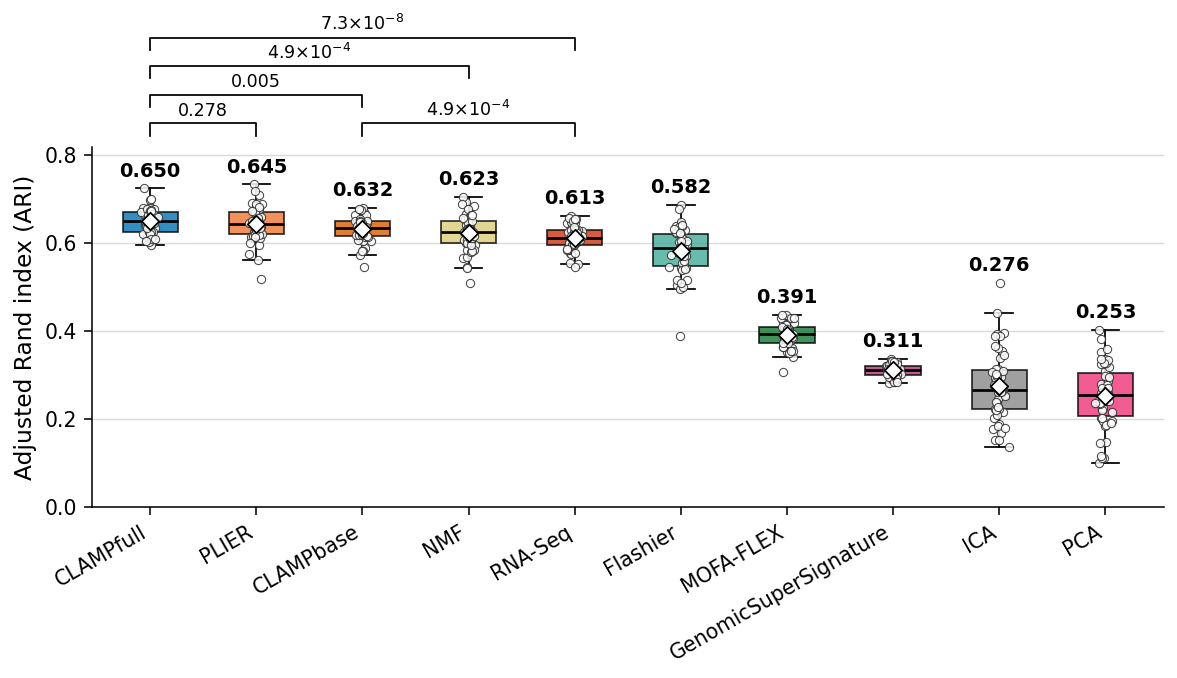

In [29]:
import re
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy.stats import mannwhitneyu

mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
})

candidate_names = [
    "best_k_gtex_CLAMP_base_kmeans_results_df",
    "best_k_gtex_CLAMP_full_kmeans_results_df",
    "best_k_gtex_PLIER_kmeans_results_df",
    "best_k_gtex_rnaseq_kmeans_results_df",
    "best_k_gtex_pca_kmeans_results_df",
    "best_k_gtex_ica_kmeans_results_df",
    "best_k_gtex_nmf_kmeans_results_df",
    "best_k_gtex_mofabc_kmeans_results_df",
    "best_k_gtex_flashier_kmeans_results_df",
    "best_k_gtex_GenomicSuperSignature_kmeans_results_df",
    # "best_k_gtex_wgcna_kmeans_results_df",
]

datasets = {name: globals().get(name) for name in candidate_names}
datasets = {
    k: v for k, v in datasets.items()
    if v is not None and "ari" in v.columns and len(v) > 0
}

# # inject RNA-Seq null distribution
# if "gtex_rnaseq_null_results" in globals():
#     _null_df = gtex_rnaseq_null_results["best_k_results_df"]
#     if _null_df is not None and "ari" in _null_df.columns and len(_null_df) > 0:
#         datasets["best_k_gtex_rnaseq_null_kmeans_results_df"] = _null_df

if len(datasets) == 0:
    raise ValueError("No valid datasets found with an 'ari' column.")

def clean_name(name: str) -> str:
    name = re.sub(r"^best_k_gtex_", "", name)
    name = re.sub(r"_kmeans_results_df$", "", name)
    return name

display_name_map = {
    "CLAMP_base": "CLAMPbase",
    "CLAMP_full": "CLAMPfull",
    "PLIER": "PLIER",
    "rnaseq": "RNA-Seq",
    # "rnaseq_null": "RNA-Seq null",
    "mofabc": "MOFA-FLEX",
    "flashier": "Flashier",
    "GenomicSuperSignature": "GenomicSuperSignature",
    "pca": "PCA",
    "ica": "ICA",
    "nmf": "NMF",
    # "wgcna": "WGCNA",
}

def get_display_name(name: str) -> str:
    cleaned = clean_name(name)
    return display_name_map.get(cleaned, cleaned)

means = {
    name: np.asarray(datasets[name]["ari"], dtype=float).mean()
    for name in datasets
}
ordered_names = sorted(means, key=lambda n: means[n], reverse=True)

data = [np.asarray(datasets[name]["ari"], dtype=float) for name in ordered_names]
labels = [get_display_name(name) for name in ordered_names]

def bh_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(n, dtype=float)
    running = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        running = min(running, val)
        adj[order[i]] = min(running, 1.0)
    return adj

def mw_p_greater(a, b):
    return mannwhitneyu(a, b, alternative="greater").pvalue

def format_q(q):
    if q >= 1e-3:
        return f"{q:.3f}"
    exponent = int(np.floor(np.log10(q)))
    coeff = q / (10 ** exponent)
    return rf"{coeff:.1f}$\times$10$^{{{exponent}}}$"

# Specific comparisons to draw
specific_pairs = [
    ("CLAMPfull", "PLIER"),
    ("CLAMPfull", "CLAMPbase"),
    ("CLAMPfull", "RNA-Seq"),
    ("CLAMPbase", "RNA-Seq"),
    ("CLAMPfull", "NMF"),
]
available_pairs = [(a, b) for a, b in specific_pairs if a in labels and b in labels]

raw_pvals = [
    mw_p_greater(data[labels.index(a)], data[labels.index(b)])
    for a, b in available_pairs
]
qvals = bh_adjust(raw_pvals)
comparisons_to_draw = [(a, b, q) for (a, b), q in zip(available_pairs, qvals)]

fig, ax = plt.subplots(figsize=(8.8, 5.6))
rng = np.random.default_rng(7)

positions = np.arange(1, len(data) + 1)

box = ax.boxplot(
    data,
    positions=positions,
    widths=0.52,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", linewidth=1.4),
    whiskerprops=dict(color="black", linewidth=0.9),
    capprops=dict(color="black", linewidth=0.9),
    boxprops=dict(edgecolor="black", linewidth=0.9),
)

for patch, label in zip(box["boxes"], labels):
    patch.set_facecolor(MODEL_COLORS.get(label, "#BBBBBB"))
    patch.set_alpha(0.80)

for x, vals in zip(positions, data):
    jitter = rng.normal(0, 0.035, size=len(vals))
    ax.scatter(
        np.full(len(vals), x) + jitter,
        vals,
        s=18,
        facecolor="white",
        edgecolor="#2b2b2b",
        linewidth=0.55,
        alpha=0.85,
        zorder=3,
    )

for x, vals in zip(positions, data):
    mean_val = np.mean(vals)
    ymax = np.max(vals)
    ax.scatter(
        x, mean_val,
        s=40,
        marker="D",
        facecolor="white",
        edgecolor="black",
        linewidth=0.9,
        zorder=4,
    )
    ax.text(
        x, ymax + 0.018,
        f"{mean_val:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.set_ylabel("Adjusted Rand index (ARI)")
ax.set_xlabel("")
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_xlim(0.45, len(data) + 0.55)
ax.set_ylim(0, 0.82)
ax.yaxis.set_major_locator(MultipleLocator(0.2))

ax.grid(axis="y", color="#D9D9D9", linewidth=0.7)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

def draw_bracket(ax, x1, x2, y, h, text):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        lw=0.9,
        c="black",
        clip_on=False,
    )
    ax.text(
        (x1 + x2) / 2,
        y + h + 0.008,
        text,
        ha="center",
        va="bottom",
        fontsize=9,
        clip_on=False,
    )

xpos = {lab: pos for lab, pos in zip(labels, positions)}

def assign_bracket_tiers(pairs_with_labels):
    """Greedily stack (a, b) brackets into non-overlapping tiers, sorted by x-span then q."""
    rows = [
        {"a": a, "b": b, "left": l, "right": r, "q": q, "span": r - l}
        for a, b, l, r, q in pairs_with_labels
    ]
    rows.sort(key=lambda d: (d["span"], d["q"]))
    levels_used = []
    for row in rows:
        tier = 0
        while True:
            if tier >= len(levels_used):
                levels_used.append([])
                break
            if not any(not (row["right"] < lo or row["left"] > hi) for lo, hi in levels_used[tier]):
                break
            tier += 1
        row["tier"] = tier
        levels_used[tier].append((row["left"], row["right"]))
    return rows

pairs_with_labels = [
    (a, b, *sorted([xpos[a], xpos[b]]), q) for a, b, q in comparisons_to_draw
]
tier_by_pair = {(r["a"], r["b"]): r["tier"] for r in assign_bracket_tiers(pairs_with_labels)}

Y_BASE, Y_STEP, h = 0.845, 0.065, 0.028

for a, b, q in comparisons_to_draw:
    x1, x2 = sorted([xpos[a], xpos[b]])
    y = Y_BASE + tier_by_pair[(a, b)] * Y_STEP
    draw_bracket(ax, x1, x2, y, h, format_q(q))

fig.subplots_adjust(left=0.11, right=0.98, bottom=0.22, top=0.68)

plt.show()

In [30]:
# Export ARI data + comparisons for fig3.ipynb Panel A (reproducible pipeline)
import pandas as pd
from pathlib import Path

FIG3_PANEL_DIR = Path(here("output/99_panels/fig3"))
FIG3_PANEL_DIR.mkdir(parents=True, exist_ok=True)

ari_export_df = pd.DataFrame({
    "method": [lab for lab, vals in zip(labels, data) for _ in vals],
    "ari": [v for vals in data for v in vals],
})
ari_export_df.to_csv(FIG3_PANEL_DIR / "ari_data.csv", index=False)

ari_comparisons_df = pd.DataFrame(comparisons_to_draw, columns=["a", "b", "q"])
ari_comparisons_df.to_csv(FIG3_PANEL_DIR / "ari_comparisons.csv", index=False)

print(f"Wrote {len(ari_export_df)} ARI rows across {ari_export_df['method'].nunique()} "
      f"methods and {len(ari_comparisons_df)} comparisons to {FIG3_PANEL_DIR}")


Wrote 500 ARI rows across 10 methods and 5 comparisons to /home/msubirana/Documents/pivlab/clamp-analyses/output/99_panels/fig3


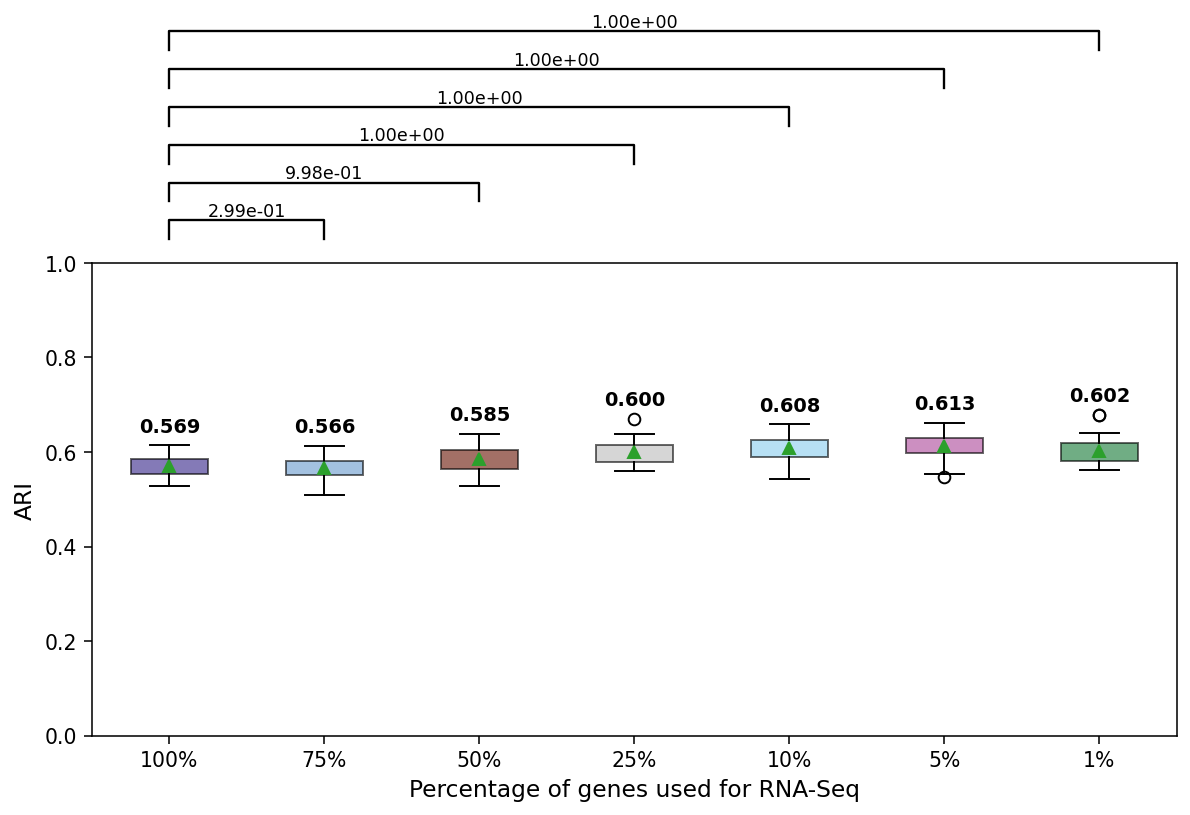

In [31]:
# RNA-Seq Gene Subsampling Comparison Plot
fraction_order = [1.0, 0.75, 0.50, 0.25, 0.10, 0.05, 0.01]
fraction_labels = ["100%", "75%", "50%", "25%", "10%", "5%", "1%"]

# Aggregate ARI values for each fraction
aggregated_data = {}
for frac, label in zip(fraction_order, fraction_labels):
    ari_values = []
    for run_label, df in best_k_rnaseq_results.items():
        if df["frac"].iloc[0] == frac:
            ari_values.extend(df["ari"].tolist())
    aggregated_data[label] = np.array(ari_values)

# Prepare data for boxplot
data = [aggregated_data[label] for label in fraction_labels]

# Create figure
fig, ax = plt.subplots(figsize=(10, 10))

box = ax.boxplot(data, tick_labels=fraction_labels, showmeans=True, patch_artist=True, medianprops={'visible': False})

# Use consistent colors from RNASEQ_FRACTION_COLORS palette
for patch, label in zip(box["boxes"], fraction_labels):
    patch.set_facecolor(get_fraction_color(label))
    patch.set_alpha(0.6)

# Add mean ARI values above each boxplot
for i, d in enumerate(data):
    mean_ari = np.mean(d)
    max_val = np.max(d)
    y_pos = max_val + 0.02
    ax.text(i + 1, y_pos, f'{mean_ari:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel("ARI")
ax.set_xlabel("Percentage of genes used for RNA-Seq")
ax.set_ylim(0, 1)

# Compare 100% vs each other fraction
top_label = fraction_labels[0]
pairs = [(top_label, label) for label in fraction_labels[1:]]

def mw_p_greater(a, b):
    """One-sided test: is a significantly greater than b?"""
    return mannwhitneyu(a, b, alternative="greater").pvalue

raw_p = [mw_p_greater(aggregated_data[a], aggregated_data[b]) for a, b in pairs]

# Use raw p-values (no correction)
pvals = np.array(raw_p)

# Draw significance bars
xpos = {label: i + 1 for i, label in enumerate(fraction_labels)}

def draw_bar(ax, x1, x2, y, h, txt):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black", clip_on=False)
    ax.text((x1 + x2) / 2, y + h, txt, ha="center", va="bottom", fontsize=9, clip_on=False)

y_start = 1.05
bar_height = 0.04
gap = 0.04
y = y_start

for (a, b), p in zip(pairs, pvals):
    x1, x2 = sorted([xpos[a], xpos[b]])
    draw_bar(ax, x1, x2, y, bar_height, f"{p:.2e}")
    y += bar_height + gap

total_height_needed = y - y_start
top_margin = 1 - (0.95 / (1 + total_height_needed * 1.5))
plt.subplots_adjust(top=top_margin)

plt.show()